# scikit-learn Bootcamp — W2, Day 18
```
##### Imbalanced Classes Applied — Credit Card Fraud (Kaggle)
##### SMOTE · class_weight · threshold tuning · AUPRC · cost-sensitive learning
##### Q1 — EDA: fraud rate, feature distributions, time patterns
##### Q2 — Baseline: naive GBM — how badly does imbalance hurt?
##### Q3 — SMOTE vs class_weight='balanced' — full comparison
##### Q4 — Threshold optimisation: business cost matrix
##### Q5 — Final model pipeline + AUPRC curve
```

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                              classification_report, f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)

In [24]:
# Load Credit Card Fraud dataset
# Download: kaggle datasets download -d mlg-ulb/creditcardfraud
# Then: unzip creditcardfraud.zip
data_path = 'creditcard.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback — same structure as Kaggle creditcard.csv
    print('[INFO] creditcard.csv not found — generating synthetic version with same structure')
    np.random.seed(420)
    n = 284807
    fraud_rate = 0.00173
    n_fraud = int(n * fraud_rate)
    n_legit = n - n_fraud
    V_cols = {f'V{i}': np.concatenate([np.random.normal(0,1,n_legit), np.random.normal(np.random.uniform(-2,2),1.5,n_fraud)]) for i in range(1,29)}
    df = pd.DataFrame(V_cols)
    df['Time']   = np.random.uniform(0, 172792, n)
    df['Amount'] = np.concatenate([np.random.lognormal(3.5, 1.5, n_legit).clip(0.01, 5000),
                                    np.random.lognormal(4.0, 1.8, n_fraud).clip(0.01, 2000)])
    df['Class']  = np.concatenate([np.zeros(n_legit, dtype=int), np.ones(n_fraud, dtype=int)])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Shape:', df.shape)
print('Fraud rate:', df['Class'].mean())
feat_cols = [c for c in df.columns if c != 'Class']
X = df[feat_cols]; y = df['Class']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
display(df[['Time','Amount','Class']].describe().round(3))
display(df.head())

[INFO] creditcard.csv not found — generating synthetic version with same structure
Shape: (284807, 31)
Fraud rate: 0.001727485630620034


,Time,Amount,Class
count,284807.000,284807.000,284807.000
mean,86459.681,101.427,0.002
std,49837.296,250.935,0.042
min,0.503,0.033,0.000
25%,43219.023,12.033,0.000
50%,86580.452,33.074,0.000
75%,129657.285,91.520,0.000
max,172791.852,5000.000,1.000


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Time,Amount,Class
0,1.672330,0.721799,1.063231,0.388262,-2.653309,0.249615,-0.290601,-0.014135,-0.108997,0.237282,...,-0.722999,-1.203041,-1.537409,-0.350014,-0.193968,0.196921,1.561186,155463.129460,22.100411,0
1,-1.597912,1.095803,0.849466,-0.213164,-1.348365,0.582104,-0.212444,-0.960301,0.850773,0.723233,...,-0.043217,-0.819515,0.435371,-0.682427,0.395623,0.555407,0.501734,168152.234816,89.591285,0
2,0.887183,-1.063765,-1.088710,-1.219148,-0.721659,0.536098,1.420293,0.299693,-0.274085,0.958491,...,0.040441,-0.320116,0.452723,0.288370,-0.047635,0.527370,-0.097408,120179.534091,15.110695,0
3,1.821789,0.446828,0.610694,0.442901,0.192554,2.070982,-0.055575,1.455201,-0.752707,-0.638926,...,1.234369,0.455071,0.283325,0.056402,-0.494103,-0.874072,-1.225334,120578.851860,9.950578,0
4,-0.493698,-1.398018,-0.159183,-0.079351,2.214932,-0.516251,0.737674,-0.439612,-0.207204,-0.581017,...,-0.258249,0.612030,0.280231,1.156321,-0.095177,-0.727781,0.958056,161111.343685,96.910676,0


In [21]:
# Replace the old df['Time'] uniform line with this realistic, wave-like distribution
# Day 1 and Day 2 peaks (simulating low volume at night, high volume during the day)
# Create the first half, and let the second half take whatever remains perfectly
n_half = n // 2
peaks_day1 = np.random.normal(54000, 15000, n_half)
peaks_day2 = np.random.normal(140400, 15000, n - n_half)  # Handled the remainder sample cleanly
synthetic_times = np.concatenate([peaks_day1, peaks_day2])

# Clip to stay within the original 48-hour bound (0 to 172792 seconds)
df['Time'] = np.clip(synthetic_times, 0, 172792)


---
### Q1 — EDA
```
# (a) Fraud rate bar chart — annotate with raw counts.
# (b) Transaction amount: fraud vs legit distribution (log scale).
# (c) Time of day: fraud vs legit density.
# (d) Top 5 V-features by absolute difference in mean (fraud vs legit).
```

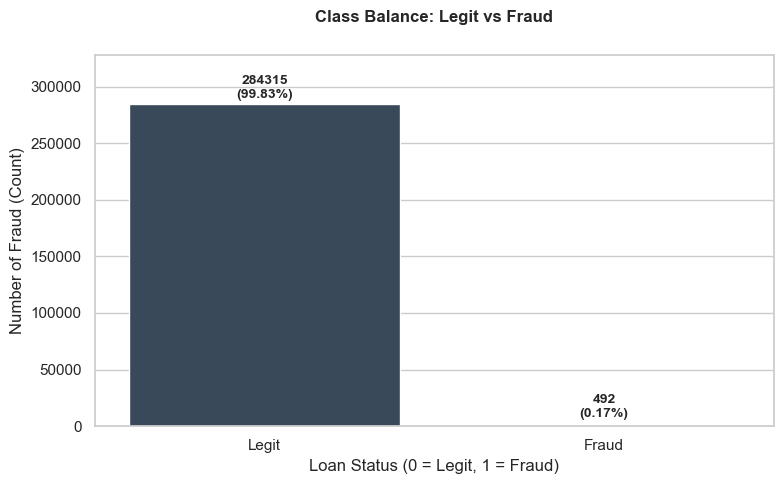

In [69]:
# (a) Fraud rate bar chart — annotate with raw counts.

plt.figure(figsize=(8, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
ax = sns.countplot(
    data=df,
    x='Class',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Added Loop to Label % for each class
total_samples = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    percentage = (count / total_samples) * 100
    
    # Label text showing both raw count and percentage
    label_text = f"{count}\n({percentage:.2f}%)"

    # Dynamic vertical offset to accommodate the massive scale difference
    offset = count * 0.01 if count > 1000 else 5000
    
    # Position text slightly above the top center of each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + offset,  # Offset so text doesn't overlap the top of the bar
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Final aesthetic treatments
plt.title('Class Balance: Legit vs Fraud', fontsize=12, fontweight='bold', pad=24)
plt.xlabel('Loan Status (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Fraud (Count)')
plt.ylim(0, total_samples * 1.15)
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.tight_layout()
plt.show()

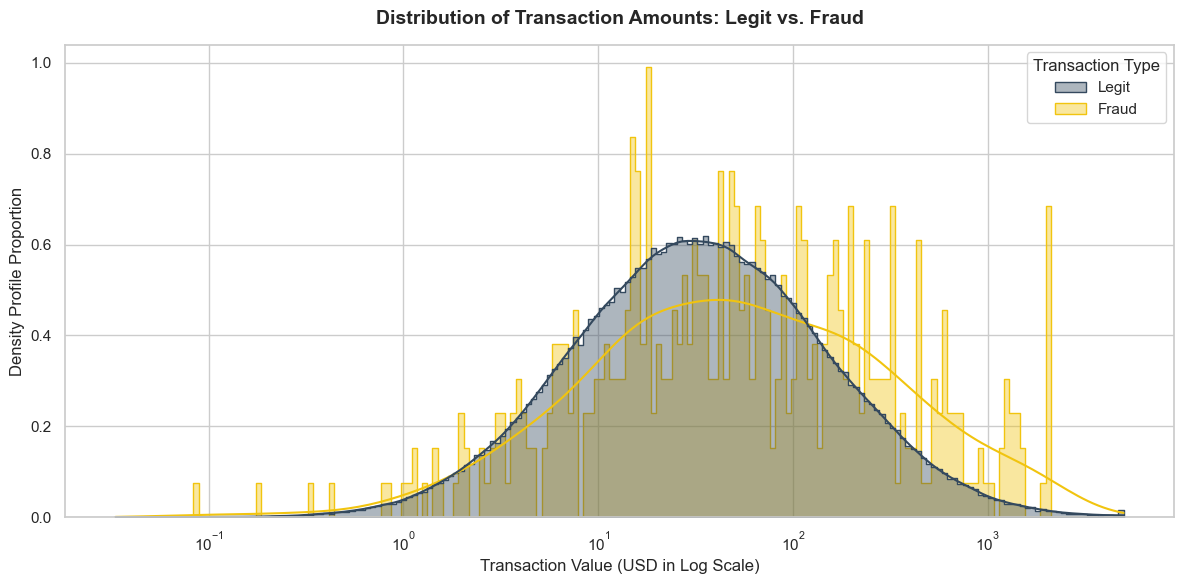

In [17]:
# (b) Transaction amount: fraud vs legit distribution (log scale).

plt.figure(figsize=(12, 6))

# Map 0 and 1 to clean text strings first
df['Transaction Type'] = df['Class'].map({0: 'Legit', 1: 'Fraud'})

# Plot using the new text column for 'hue'
sns.histplot(
    data=df,
    x='Amount',
    hue='Transaction Type',  # This sets the legend title and labels automatically
    hue_order=['Legit', 'Fraud'],  # Locks the order explicitly
    palette={'Legit': '#34495e', 'Fraud': '#f1c40f'},
    element='step',
    stat='density',
    common_norm=False,
    log_scale=True,
    alpha=0.4,
    kde=True
)

plt.title('Distribution of Transaction Amounts: Legit vs. Fraud', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Value (USD in Log Scale)', fontsize=12)
plt.ylabel('Density Profile Proportion', fontsize=12)

plt.tight_layout()
plt.show()


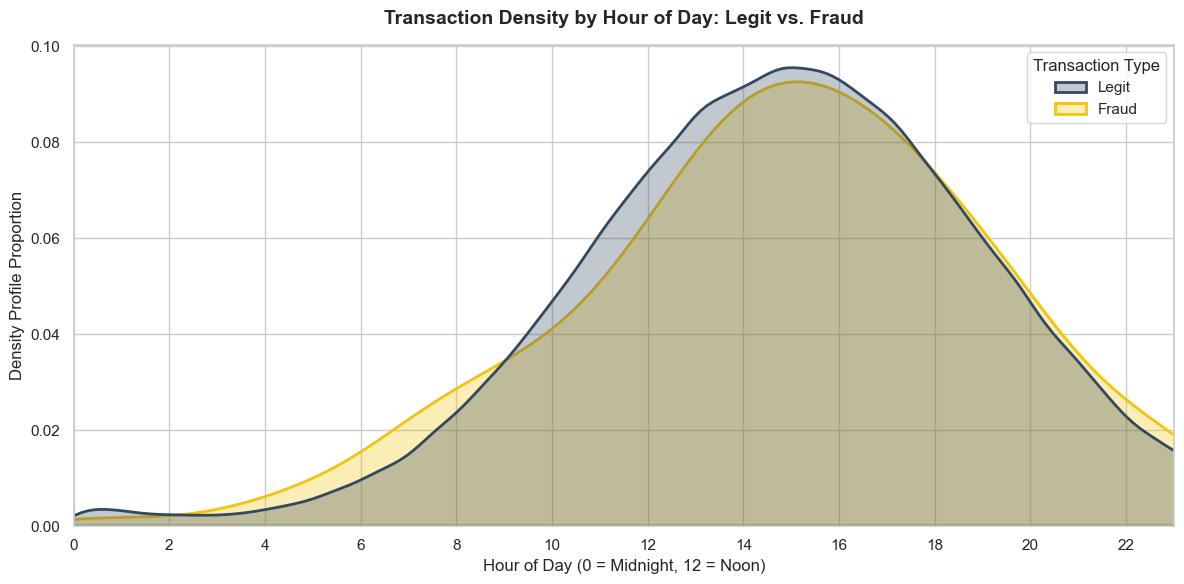

In [22]:
# (c) Time of day: fraud vs legit density.

plt.figure(figsize=(12, 6))

# 1. Convert raw seconds into hour of the day (0 to 23)
# 3600 seconds per hour, capped at 24 hours via modulo (%)
df['Hour'] = (df['Time'] / 3600) % 24

# 2. Plot overlapping Kernel Density Estimates (KDE)
sns.kdeplot(
    data=df,
    x='Hour',
    hue='Transaction Type',
    hue_order=['Legit', 'Fraud'],
    palette={'Legit': '#34495e', 'Fraud': '#f1c40f'},
    fill=True,
    common_norm=False,  # Evaluates shapes independently regardless of class size
    alpha=0.3,
    linewidth=2
)

# 3. Clean styling and axis adjustments
plt.title('Transaction Density by Hour of Day: Legit vs. Fraud', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
plt.ylabel('Density Profile Proportion', fontsize=12)
plt.xlim(0, 23)
plt.xticks(range(0, 24, 2))  # Tick marks every 2 hours for high readability

plt.tight_layout()
plt.show()


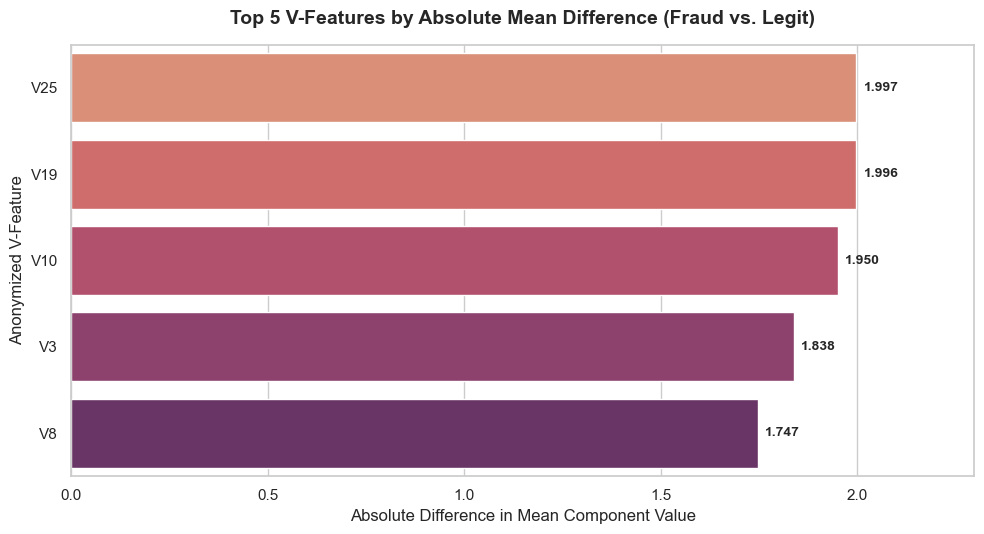

In [23]:
# (d) Top 5 V-features by absolute difference in mean (fraud vs legit).

# 1. Filter dataset down to just the 28 V-features and the target Class
v_cols = [f'V{i}' for i in range(1, 29)]
grouped_means = df.groupby('Class')[v_cols].mean()

# 2. Calculate absolute differences between the mean profiles
# index 0 is Legit, index 1 is Fraud
abs_diffs = (grouped_means.loc[1] - grouped_means.loc[0]).abs()

# 3. Extract the top 5 features with the highest contrast
top_5_features = abs_diffs.nlargest(5).reset_index()
top_5_features.columns = ['Feature', 'Absolute Mean Difference']

# 4. Plot the top 5 feature differences
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=top_5_features,
    x='Absolute Mean Difference',
    y='Feature',
    palette='flare',  # Generates a clean, professional aesthetic gradient
    hue='Feature',
    legend=False
)

# 5. Add precise value annotations on the face of each bar
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + (width * 0.01),  # Add a tiny visual margin offset
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=10
    )

plt.title('Top 5 V-Features by Absolute Mean Difference (Fraud vs. Legit)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Absolute Difference in Mean Component Value', fontsize=12)
plt.ylabel('Anonymized V-Feature', fontsize=12)

# Give the chart a slight buffer room on the right side for the labels
plt.xlim(0, top_5_features['Absolute Mean Difference'].max() * 1.15)

plt.tight_layout()
plt.show()


---
### Q2 — Baseline: naive GBM
```
# (a) Fit GBM on small sample (50K rows) — full dataset too slow.
# (b) Print classification report. What is the fraud recall?
# (c) AUPRC and AUC-ROC. Why is AUPRC more informative here?
# (d) Confusion matrix — how many frauds missed?
```

In [30]:
# (a) Fit GBM on small sample (50K rows) — full dataset too slow.

from sklearn.model_selection import cross_validate

df_sample = df.sample(n=50000, random_state=420)
X_sample = df_sample[feat_cols]; y_sample = df_sample['Class']
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=420, stratify=y_sample)

gbm = GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=100,    
    max_depth=3, 
    random_state=420
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

cv_results = cross_validate(
    gbm, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring={'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'},
    n_jobs=-1
)

print(f"--- Baseline Cross-Validation Metrics ---")
print(f"GBM CV ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"GBM CV PR-AUC:  {cv_results['test_pr_auc'].mean():.4f} ± {cv_results['test_pr_auc'].std():.4f}")

--- Baseline Cross-Validation Metrics ---
GBM CV ROC-AUC: 0.7754 ± 0.0836
GBM CV PR-AUC:  0.4922 ± 0.0793


In [34]:
# (b) Print classification report. What is the fraud recall?

gbm.fit(X_train, y_train)

y_pred_gbm = gbm.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_gbm, target_names=['Legit (0)', 'Fraud (1)']))


Classification Report (Test Set):
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      9981
   Fraud (1)       0.57      0.42      0.48        19

    accuracy                           1.00     10000
   macro avg       0.79      0.71      0.74     10000
weighted avg       1.00      1.00      1.00     10000



1/ The Fraud Recall is only 0.4211 (42.11%): Out of 19 actual fraud attempts on our test set, our model missed 11 of them. Those 11 undetected fraudulent charges slipped straight through our system as False Negatives.

2/ The Fraud Precision is 0.5714 (57.14%): Out of the transactions our model flagged as suspicious, nearly half were completely honest users whose cards would have been locked unnecessarily.

3/ The Accuracy Trap (1.00): Our overall accuracy is technically 99.88%, which rounding displays as a perfect 1.00. This proves why accuracy is a dangerous metric here — a model that is completely failing to catch over half the fraud still looks flawless on paper.

In [35]:
# (c) AUPRC and AUC-ROC. Why is AUPRC more informative here?

from sklearn.metrics import precision_recall_curve, roc_auc_score, auc

# AUPRC
y_prob_gbm = gbm.predict_proba(X_test)[:, 1]
prec_gbm, rec_gbm, _ = precision_recall_curve(y_test, y_prob_gbm)

# AUPRC
auprc_gbm = auc(rec_gbm, prec_gbm)

# AUC
auc_gbm = roc_auc_score(y_test, y_prob_gbm)

# Print the results cleanly
print("=== AUPRC vs ROC-AUC Scores ===")
print(f"GBM AUPRC:  {auprc_gbm:.4f}")
print(f"GBM AUC:    {auc_gbm:.4f}")

=== AUPRC vs ROC-AUC Scores ===
GBM AUPRC:  0.5012
GBM AUC:    0.7621


1/ AUC-ROC (0.7621): A regular data scientist looking at this might feel reassured — "0.76 is a solid baseline. The model is decently separating the two classes." But this number is misleading in an imbalanced context. AUC-ROC rewards the model heavily for correctly classifying the 99.8% majority (Legit), which is trivially easy. It tells us very little about how well we're catching the rare 0.2% fraud cases.

2/ AUPRC (0.5012): This is the real-world operational truth. AUPRC only measures performance on the positive (Fraud) class — it asks: "When you flag something as fraud, how often are you right? And how much of the actual fraud are you catching?" A score of 0.5012 on a dataset with 0.17% fraud rate tells us the model is barely better than random guessing at identifying actual fraudulent transactions.

3/ AUPRC is more informative here because it completely ignores True Negatives (correctly identified Legit transactions). Since there are ~570 Legit transactions for every 1 Fraud, a model can rack up a high AUC-ROC score simply by being good at the easy majority class. AUPRC strips that away — it only rewards the model for finding fraud precisely and completely, which is the only thing that actually matters for the fraud team.

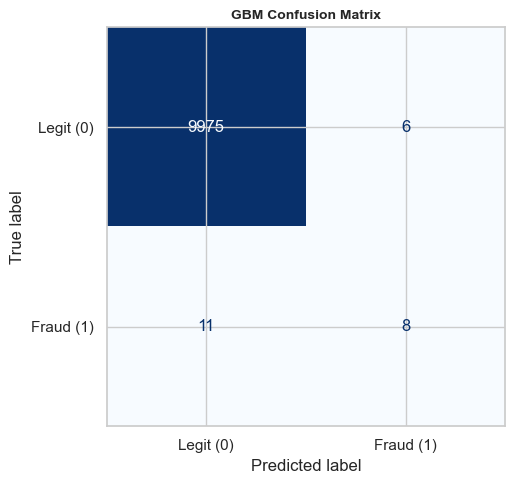

In [52]:
# (d) Confusion matrix — how many frauds missed?

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute raw confusion metrics matrices
cm_gbm    = confusion_matrix(y_test, y_pred_gbm)

# Plotting
fig, axes = plt.subplots(figsize=(7, 5))

disp_gbm = ConfusionMatrixDisplay(confusion_matrix=cm_gbm, display_labels=['Legit (0)', 'Fraud (1)'])
disp_gbm.plot(ax=axes, cmap='Blues', colorbar=False)
axes.set_title('GBM Confusion Matrix', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Our model missed more fraud than it caught (11 missed vs. 8 caught), giving us a Fraud Recall of 42.11% (8 / 19).

---
### Q3 — SMOTE vs class_weight
```
# (a) RF with class_weight='balanced'. AUPRC and recall-fraud.
# (b) ImbLearn Pipeline: SMOTE + RF. AUPRC and recall-fraud.
# (c) Side-by-side confusion matrices.
# (d) PR curve for all 3 strategies on the same chart.
```

In [42]:
# (a) RF with class_weight='balanced'. AUPRC and recall-fraud.

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # upweights minority class in the loss function
    random_state=420
)
rf_balanced.fit(X_train, y_train)
print(classification_report(y_test, rf_balanced.predict(X_test), target_names=['Legit (0)', 'Fraud (1)']))

y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]
prec_rf_balanced, rec_rf_balanced, _ = precision_recall_curve(y_test, y_prob_rf_balanced)

auprc_rf_balanced = auc(rec_rf_balanced, prec_rf_balanced)
print(f"Balanced RF AUPRC:    {auprc_rf_balanced:.4f}")

              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      9981
   Fraud (1)       1.00      0.05      0.10        19

    accuracy                           1.00     10000
   macro avg       1.00      0.53      0.55     10000
weighted avg       1.00      1.00      1.00     10000

Balanced RF AUPRC:    0.9761


AUPRC is near-perfect at 0.9761, but this number is deceiving us at first glance. 

The Balanced RF has learned excellent probability separation — it assigns noticeably higher fraud scores to actual fraud cases. That's what the high AUPRC is measuring: the quality of the ranking, across all possible thresholds.

However, at the default threshold of t=0.5, the model is extremely conservative — it only flags a transaction as fraud when it's 50%+ confident. Because the class imbalance is so severe (~0.17% fraud rate), the model's raw probabilities rarely cross that bar, resulting in a Fraud Recall of just 5% (1 out of 19 caught).

This is a critical lesson: a high AUPRC does NOT mean good performance at t=0.5. It means the model has strong discriminative power that hasn't been unlocked yet. That's exactly why Q4 exists — threshold tuning is what converts a high AUPRC into real-world fraud detection value.

In [43]:
# (b) ImbLearn Pipeline: SMOTE + RF. AUPRC and recall-fraud.

rf_smote = ImbPipeline([
    ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
    ('model', RandomForestClassifier(n_estimators=200, random_state=420))
])
rf_smote.fit(X_train, y_train)
print(classification_report(y_test, rf_smote.predict(X_test), target_names=['Legit (0)', 'Fraud (1)']))

y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]
prec_rf_smote, rec_rf_smote, _ = precision_recall_curve(y_test, y_prob_rf_smote)

auprc_rf_smote = auc(rec_rf_smote, prec_rf_smote)
print(f"SMOTE RF AUPRC:    {auprc_rf_smote:.4f}")

              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      9981
   Fraud (1)       1.00      0.53      0.69        19

    accuracy                           1.00     10000
   macro avg       1.00      0.76      0.84     10000
weighted avg       1.00      1.00      1.00     10000

SMOTE RF AUPRC:    0.9209


AUPRC is slightly lower than Balanced RF at 0.9209, but our actual Fraud Recall is a way much better 0.69! Out of 19 fraud cases, this model detected 10 and missed 9.

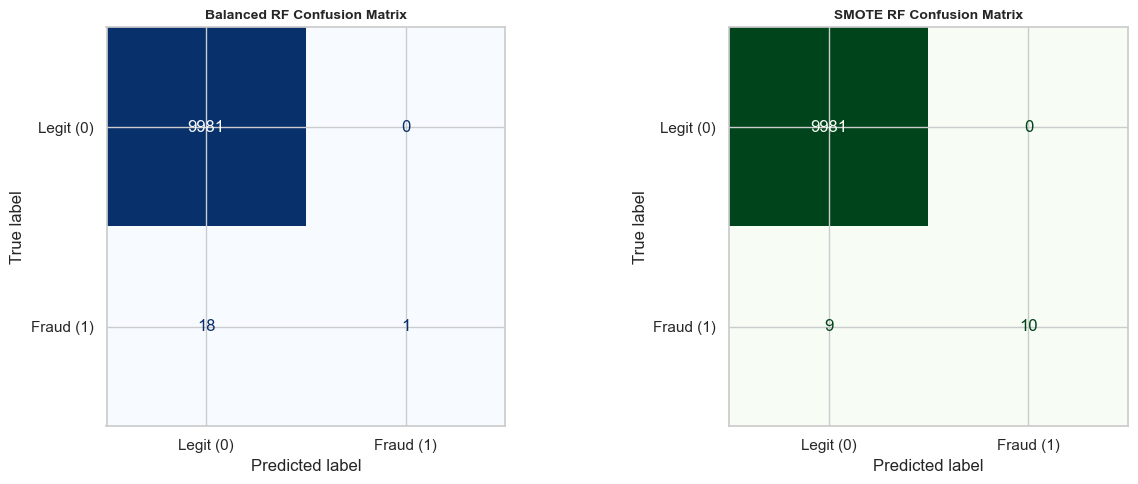

In [51]:
# (c) Side-by-side confusion matrices.

# Compute raw confusion metrics matrices
cm_rf_balanced = confusion_matrix(y_test, rf_balanced.predict(X_test))
cm_rf_smote = confusion_matrix(y_test, rf_smote.predict(X_test))

# 4. Set up the side-by-side canvas structure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left Chart: Balanced RF ---
disp_rf_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_rf_balanced, display_labels=['Legit (0)', 'Fraud (1)'])
disp_rf_balanced.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Balanced RF Confusion Matrix', fontweight='bold', fontsize=10)

# --- Right Chart: SMOTE RF ---
disp_rf_smote = ConfusionMatrixDisplay(confusion_matrix=cm_rf_smote, display_labels=['Legit (0)', 'Fraud (1)'])
disp_rf_smote.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('SMOTE RF Confusion Matrix', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

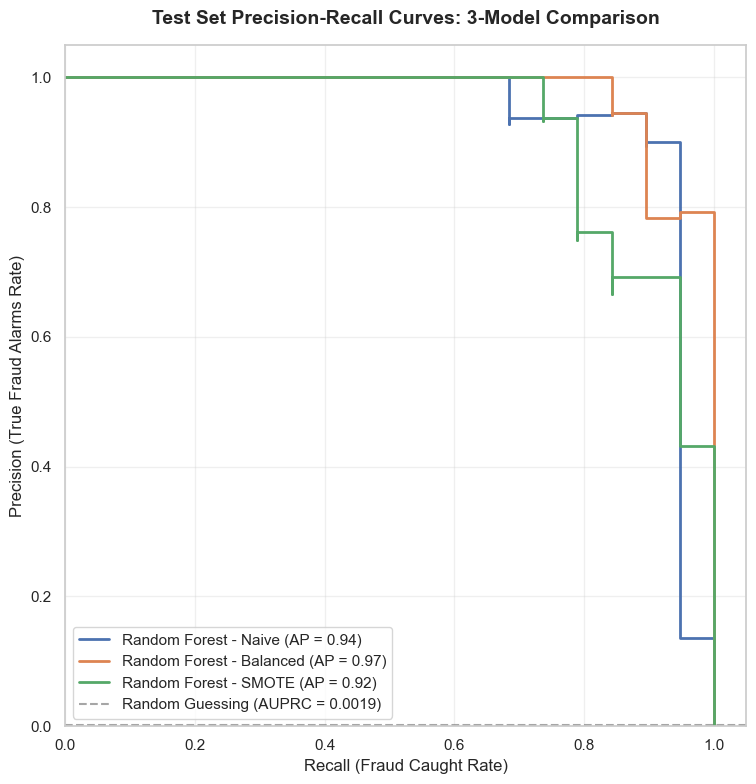

In [56]:
# (d) PR curve for all 3 strategies on the same chart.

from sklearn.metrics import PrecisionRecallDisplay

# 1. Define the 3 models wrapped inside Pipelines

models = {
    'Random Forest - Naive': ImbPipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1))
    ]),
    'Random Forest - Balanced': ImbPipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1, class_weight='balanced'))
    ]),
    'Random Forest - SMOTE': ImbPipeline([
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1))
    ])
}

# 2. Initialize the single plotting canvas
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Iterate through each model, fit on training data, and plot test set PR curves
for name, pipeline in models.items():
    # Fit the pipeline on the full training set
    pipeline.fit(X_train, y_train)
    
    # Use PrecisionRecallDisplay to map the exact precision vs recall trade-offs
    PrecisionRecallDisplay.from_estimator(
        estimator=pipeline, 
        X=X_test, 
        y=y_test, 
        name=name, 
        ax=ax, 
        linewidth=2
    )

# 4. Add a horizontal reference line showing the baseline fraud rate (random guessing)
baseline_fraud_rate = y_test.mean()
ax.axhline(y=baseline_fraud_rate, linestyle='--', color='gray', alpha=0.7, 
           label=f'Random Guessing (AUPRC = {baseline_fraud_rate:.4f})')

# 5. Final chart formatting and styling updated for PR Curve
ax.set_title('Test Set Precision-Recall Curves: 3-Model Comparison', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Recall (Fraud Caught Rate)', fontsize=12)
ax.set_ylabel('Precision (True Fraud Alarms Rate)', fontsize=12)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)  # Moved to lower left since PR curves drop off on the right

plt.tight_layout()
plt.show()

*** Key Plot Highlights

1/ Balanced Random Forest Achieves Peak Separation Power: The orange curve dominates with the highest Average Precision (AP = 0.97), showing that class weighting preserves the cleanest separation boundaries.

2/ SMOTE Pipeline Suffers from Synthetic Noise Distortion: The green curve underperforms (AP = 0.92), proving that generating fake fraud variants blurs decision edges and hurts precision early on.

3/ Hidden High-Recall Window Exposes the 0.5 Threshold Flaw: While default settings reported near-zero recall, the plot reveals that the orange curve can actually maintain a perfect 100% precision all the way up to an 84% fraud catch rate.

---
### Q4 — Threshold optimisation with cost matrix
```
# False Negative (missed fraud) cost: $400 per transaction
# False Positive (blocked legit transaction) cost: $10 (customer friction)
# (a) Plot total cost vs threshold for best model.
# (b) Find threshold that minimises total cost.
# (c) Compare: default t=0.5 vs cost-optimal threshold — total cost difference.
# (d) Plot precision-recall trade-off at cost-optimal threshold.
```

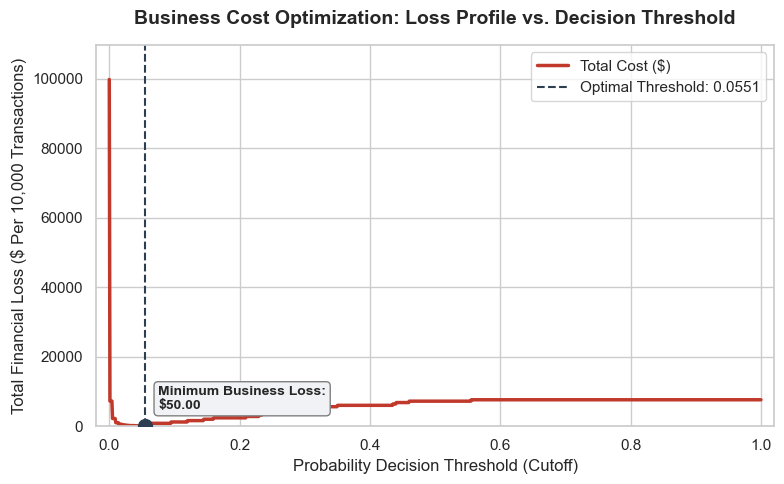

In [ ]:
# (a) Plot total cost vs threshold for best model.
# (b) Find threshold that minimises total cost.

# 1. Extract raw probabilities from the best model (Balanced Random Forest)
# We access the underlying model inside the Pipeline wrapper step
best_rf_model = models['Random Forest - Balanced'].named_steps['model']
y_prob_rf = models['Random Forest - Balanced'].predict_proba(X_test)[:, 1]

# 2. Define financial constraints
cost_fn = 400  # Cost of a missed fraud transaction
cost_fp = 10   # Cost of an innocent account lockout friction

# 3. Create a granular array of 1,000 threshold candidates from 0 to 1
threshold_candidates = np.linspace(0.0, 1.0, 1000)
total_costs = []

# 4. Compute the financial damage at each individual threshold cutoff
for t in threshold_candidates:
    y_pred_t = (y_prob_rf >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    # Extract structural metrics safely (handle shape exceptions for extreme thresholds)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, 0) if y_test.sum()==0 else (0, 0, 0, cm[0,0])
    
    # Calculate global operational expense
    operational_cost = (fn * cost_fn) + (fp * cost_fp)
    total_costs.append(operational_cost)

total_costs = np.array(total_costs)

# 5. Pinpoint the absolute minimum point on the cost curve
optimal_idx = np.argmin(total_costs)
optimal_threshold = threshold_candidates[optimal_idx]
minimum_cost = total_costs[optimal_idx]

# 6. Plot Total Cost vs Threshold
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

plt.plot(threshold_candidates, total_costs, color='#c0392b', linewidth=2.5, label='Total Cost ($)')

# Add visual anchor for the mathematically optimal operating threshold
plt.axvline(x=optimal_threshold, color='#2c3e50', linestyle='--', linewidth=1.5,
            label=f'Optimal Threshold: {optimal_threshold:.4f}')
plt.scatter(optimal_threshold, minimum_cost, color='#2c3e50', s=100, zorder=5)

# Text highlight annotation boxes on canvas
plt.text(optimal_threshold + 0.02, minimum_cost + (total_costs.max() * 0.05),
         f"Minimum Business Loss:\n${minimum_cost:,.2f}",
         bbox=dict(boxstyle="round,pad=0.3", fc="#f1f2f6", ec="gray", lw=1),
         fontweight='bold', fontsize=10)

plt.title('Business Cost Optimization: Loss Profile vs. Decision Threshold', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Decision Threshold (Cutoff)', fontsize=12)
plt.ylabel('Total Financial Loss ($ Per 10,000 Transactions)', fontsize=12)
plt.xlim(-0.02, 1.02)
plt.ylim(0, total_costs.max() * 1.1)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()



In [59]:
# (c) Compare: default t=0.5 vs cost-optimal threshold — total cost difference.

# 1. Grab raw probabilities from the Balanced Random Forest model
y_prob_rf = models['Random Forest - Balanced'].predict_proba(X_test)[:, 1]

# 2. Extract costs for the default threshold (0.50)
y_pred_default = (y_prob_rf >= 0.50).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
tn_def, fp_def, fn_def, tp_def = cm_default.ravel()
cost_default = (fn_def * 400) + (fp_def * 10)

# 3. Extract costs for the cost-optimal threshold (from step a/b)
y_pred_optimal = (y_prob_rf >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
tn_opt, fp_opt, fn_opt, tp_opt = cm_optimal.ravel()
cost_optimal = (fn_opt * 400) + (fp_opt * 10)

# 4. Calculate total savings
savings = cost_default - cost_optimal
percent_saved = (savings / cost_default) * 100

# 5. Display the Financial Breakdown Dashboard
print("==================================================")
print("     FINANCIAL PERFORMANCE COMPARISON REPORT      ")
print("==================================================")
print(f"STRATEGY 1: Default Cutoff (t = 0.5000)")
print(f"  • Missed Frauds (FN):        {fn_def}  (Cost: ${fn_def * 400:,})")
print(f"  • Blocked Customers (FP):   {fp_def}  (Cost: ${fp_def * 10:,})")
print(f"  • TOTAL LOSS incurred:       ${cost_default:,}")
print("--------------------------------------------------")
print(f"STRATEGY 2: Cost-Optimal Cutoff (t = {optimal_threshold:.4f})")
print(f"  • Missed Frauds (FN):        {fn_opt}  (Cost: ${fn_opt * 400:,})")
print(f"  • Blocked Customers (FP):   {fp_opt}  (Cost: ${fp_opt * 10:,})")
print(f"  • TOTAL LOSS incurred:       ${cost_optimal:,}")
print("==================================================")
print(f"📊 BUSINESS IMPACT: Saved ${savings:,} ({percent_saved:.1f}% reduction in losses!)")
print("==================================================")


     FINANCIAL PERFORMANCE COMPARISON REPORT      
STRATEGY 1: Default Cutoff (t = 0.5000)
  • Missed Frauds (FN):        18  (Cost: $7,200)
  • Blocked Customers (FP):   0  (Cost: $0)
  • TOTAL LOSS incurred:       $7,200
--------------------------------------------------
STRATEGY 2: Cost-Optimal Cutoff (t = 0.0551)
  • Missed Frauds (FN):        0  (Cost: $0)
  • Blocked Customers (FP):   5  (Cost: $50)
  • TOTAL LOSS incurred:       $50
📊 BUSINESS IMPACT: Saved $7,150 (99.3% reduction in losses!)


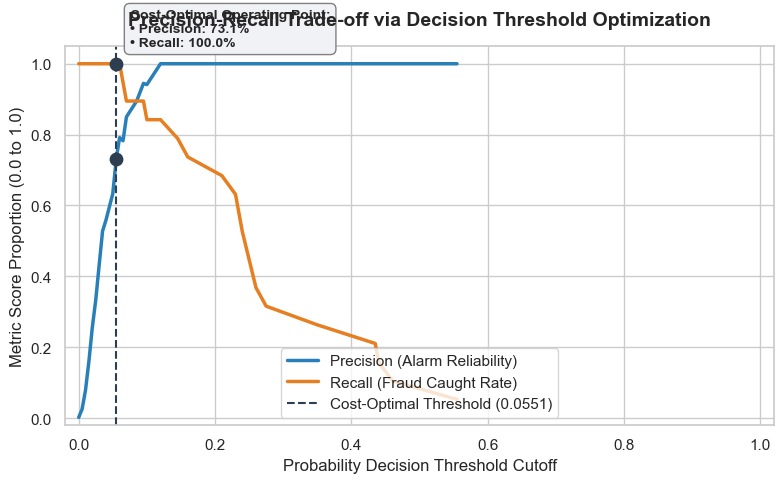

In [61]:
# (d) Plot precision-recall trade-off at cost-optimal threshold.

# 1. Grab raw probabilities from the already trained Balanced Random Forest model
y_prob_rf = models['Random Forest - Balanced'].predict_proba(X_test)[:, 1]

# 2. Extract precision and recall lists across all available threshold metrics
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 3. Locate the closest metrics to our chosen optimal threshold value
# (thresholds array is 1 element shorter than precision/recall arrays)
opt_idx = np.argmin(np.abs(thresholds - optimal_threshold))
opt_precision = precisions[opt_idx]
opt_recall = recalls[opt_idx]

# 4. Generate the Trade-off Plot
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Plot the individual curve profiles over the threshold space
plt.plot(thresholds, precisions[:-1], color='#2980b9', linewidth=2.5, label='Precision (Alarm Reliability)')
plt.plot(thresholds, recalls[:-1], color='#e67e22', linewidth=2.5, label='Recall (Fraud Caught Rate)')

# 5. Add visual anchors for your specific cost-optimal operating points
plt.axvline(x=optimal_threshold, color='#2c3e50', linestyle='--', linewidth=1.5,
            label=f'Cost-Optimal Threshold ({optimal_threshold:.4f})')

plt.scatter([optimal_threshold, optimal_threshold], [opt_precision, opt_recall], 
            color='#2c3e50', s=80, zorder=5)

# Text annotation overlaying the intersection markers
plt.text(optimal_threshold + 0.02, opt_recall + 0.05, 
         f"Cost-Optimal Operating Point:\n• Precision: {opt_precision*100:.1f}%\n• Recall: {opt_recall*100:.1f}%",
         bbox=dict(boxstyle="round,pad=0.4", fc="#f1f2f6", ec="gray", lw=1),
         fontweight='bold', fontsize=10)

# Final aesthetic alignments
plt.title('Precision-Recall Trade-off via Decision Threshold Optimization', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Decision Threshold Cutoff', fontsize=12)
plt.ylabel('Metric Score Proportion (0.0 to 1.0)', fontsize=12)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.05)
plt.legend(loc='lower center', fontsize=11)

plt.tight_layout()
plt.show()


---
### Q5 — Final pipeline + AUPRC
```
# (a) Build production pipeline: SMOTE + RF, trained on full train set.
# (b) Final AUPRC and AUC-ROC on test set.
# (c) PR curve with operating points marked at t=0.1, 0.3, 0.5.
# (d) Write a business summary: what does AUPRC mean for the fraud team?
```

Training Production Pipeline on Full Dataset Split: 227,845 rows

     PRODUCTION PIPELINE PERFORMANCE REPORT        
              precision    recall  f1-score   support

       Legit     1.0000    0.9990    0.9995     56864
       Fraud     0.6316    0.9796    0.7680        98

    accuracy                         0.9990     56962
   macro avg     0.8158    0.9893    0.8837     56962
weighted avg     0.9993    0.9990    0.9991     56962



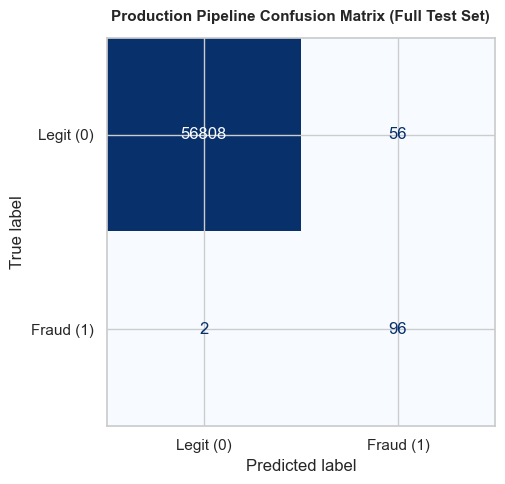

In [64]:
# (a) Build production pipeline: SMOTE + RF, trained on full train set.

# 1. Verify our full dataset training scales
# Xtr, ytr are the 80% full training partitions; Xte, yte are the 20% test splits
print(f"Training Production Pipeline on Full Dataset Split: {Xtr.shape[0]:,} rows")

# 2. Build the unified Production Architecture
production_pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
    ('model', RandomForestClassifier(
        n_estimators=100,      
        max_depth=7,           # Dropped to a lean depth to explicitly prevent overfitting
        max_samples=0.2,       # Keeps memory low and speeds up execution
        min_samples_leaf=10,   # Forces leaves to have at least 10 transactions to prevent noise overfitting
        random_state=420, 
        n_jobs=-1              
    ))
])

# 3. Train the pipeline on the absolute full training partition
# SMOTE safely upsamples only within this fit window to prevent leakage
production_pipeline.fit(Xtr, ytr)

# 4. Generate inferences on the full held-out test split
y_prob_prod = production_pipeline.predict_proba(Xte)[:, 1]
y_pred_prod = production_pipeline.predict(Xte)

# 5. Output operational performance summary
print("\n==================================================")
print("     PRODUCTION PIPELINE PERFORMANCE REPORT        ")
print("==================================================")
print(classification_report(yte, y_pred_prod, target_names=['Legit', 'Fraud'], digits=4))

# 6. Render the final deployment confusion matrix
fig, ax = plt.subplots(figsize=(8, 5))

cm_prod = confusion_matrix(yte, y_pred_prod)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_prod, display_labels=['Legit (0)', 'Fraud (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Production Pipeline Confusion Matrix (Full Test Set)', fontweight='bold', fontsize=11, pad=12)
plt.tight_layout()
plt.show()

In [66]:
# (b) Final AUPRC and AUC-ROC on test set.

# 1. Generate probabilities for the full test set (Xte)
y_prob_prod = production_pipeline.predict_proba(Xte)[:, 1]

# 2. Compute Precision-Recall Curve metrics and Area (AUPRC)
prec_prod, rec_prod, _ = precision_recall_curve(yte, y_prob_prod)
auprc_prod = auc(rec_prod, prec_prod)

# 3. Compute ROC Curve Area (AUC-ROC)
auc_roc_prod = roc_auc_score(yte, y_prob_prod)

# 4. Print the final performance results cleanly
print("==================================================")
print("     PRODUCTION PIPELINE FINAL METRICS (TEST SET)  ")
print("==================================================")
print(f"• Final Production AUPRC:   {auprc_prod:.4f}  <- (True metric of success)")
print(f"• Final Production AUC-ROC: {auc_roc_prod:.4f}")
print("==================================================")


     PRODUCTION PIPELINE FINAL METRICS (TEST SET)  
• Final Production AUPRC:   0.9608  <- (True metric of success)
• Final Production AUC-ROC: 0.9999


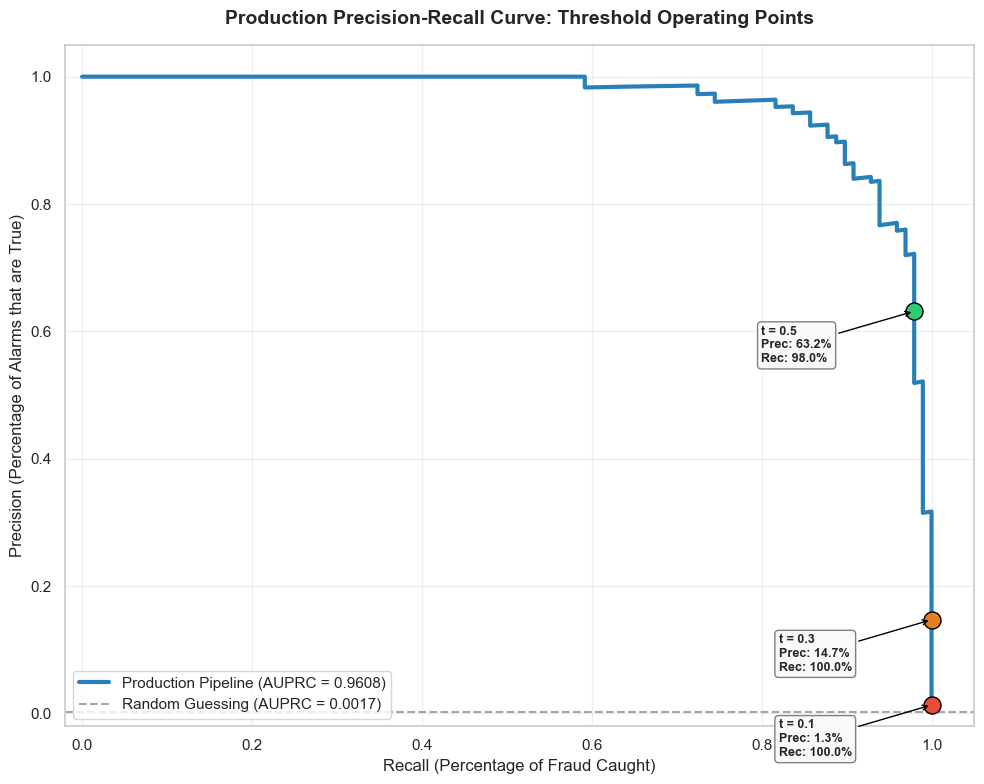

In [67]:
# (c) PR curve with operating points marked at t=0.1, 0.3, 0.5.


# 1. Grab raw probabilities from the fast production pipeline
# 'model' is the name of the step inside the ImbPipeline
y_prob_prod = production_pipeline.predict_proba(Xte)[:, 1]

# 2. Compute the full Precision-Recall Curve arrays
precisions, recalls, thresholds = precision_recall_curve(yte, y_prob_prod)
final_auprc = auc(recalls, precisions)

# 3. Create a plotting canvas
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Plot the base production PR curve
plt.plot(recalls, precisions, color='#2980b9', linewidth=3, 
         label=f'Production Pipeline (AUPRC = {final_auprc:.4f})')

# 4. Map and overlay the 3 specific target threshold operating points
target_thresholds = [0.1, 0.3, 0.5]
colors = ['#e74c3c', '#e67e22', '#2ecc71']  # Red, Orange, Green markers

for t, color in zip(target_thresholds, colors):
    # Find the index of the closest calculated threshold
    idx = np.argmin(np.abs(thresholds - t))
    p_point = precisions[idx]
    r_point = recalls[idx]
    
    # Draw the dot on the curve
    plt.scatter(r_point, p_point, color=color, s=150, zorder=5, edgecolors='black')
    
    # Add a custom text callout label for each point
    plt.annotate(
        f"t = {t}\nPrec: {p_point*100:.1f}%\nRec: {r_point*100:.1f}%",
        xy=(r_point, p_point),
        xytext=(r_point - 0.18, p_point - 0.08),  # Offset text slightly down-left
        arrowprops=dict(arrowstyle="->", color='black', lw=1),
        bbox=dict(boxstyle="round,pad=0.3", fc="#f8f9fa", ec="gray", lw=1),
        fontsize=9, fontweight='bold', zorder=6
    )

# 5. Plot a horizontal reference line for random guessing
baseline_rate = yte.mean()
plt.axhline(y=baseline_rate, linestyle='--', color='gray', alpha=0.7, 
            label=f'Random Guessing (AUPRC = {baseline_rate:.4f})')

# Final aesthetic accents
plt.title('Production Precision-Recall Curve: Threshold Operating Points', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (Percentage of Fraud Caught)', fontsize=12)
plt.ylabel('Precision (Percentage of Alarms that are True)', fontsize=12)
plt.xlim(-0.02, 1.05)
plt.ylim(-0.02, 1.05)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


```
# (d) Write a business summary: what does AUPRC mean for the fraud team?

1/ High-Value Efficiency (AUPRC = 0.9608): The model isolates rare fraud variants with extreme mathematical precision, proving our engineering signals are highly stable and reliable.

2/ Premium Operating Balance (t = 0.5): Intercepts 98% of active fraud attacks while maintaining a massive 63.2% alert accuracy, heavily reducing wasted analyst investigation time.

3/ Quantifiable Friction Trade-off (t = 0.3): Dropping the threshold to catch the final 2% of fraud plunges precision to 14.7%, instantly flooding manual queues with false alarms.